# MISION: Construir los Instrumentos

**Objetivo:** Crear features que capturen la degradacion progresiva del motor. Los sensores crudos tienen ruido — necesitamos amplificar la senal.

---

### Estrategia

1. Eliminar sensores/settings constantes (ya identificados en el EDA)
2. Normalizar por motor (MinMaxScaler para compatibilidad con LSTM)
3. Rolling features: media y desviacion estandar movil
4. Features de tendencia: pendiente de los ultimos ciclos
5. Preparar datos de test con el mismo pipeline

**Regla de oro:** El feature engineering es donde se ganan (o pierden) las batallas de ML.

## 1. Imports y Carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
HEALTHY = '#2ecc71'
DEGRADED = '#f39c12'
CRITICAL = '#e74c3c'
NEUTRAL = '#3498db'

import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
data_dir = os.path.join(project_root, "data", "cmapss")
processed_dir = os.path.join(data_dir, "processed")

df_train = pd.read_parquet(os.path.join(processed_dir, 'train_FD001_with_rul.parquet'))
print(f"Train shape: {df_train.shape}")

Train shape: (20631, 27)


## 2. Eliminar Columnas Constantes

In [2]:
# Sensores y settings constantes (varianza ~0)
constant_cols = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 
                 'sensor_16', 'sensor_18', 'sensor_19', 'op3']

df_train.drop(columns=constant_cols, inplace=True)
print(f"Eliminadas {len(constant_cols)} columnas constantes: {constant_cols}")
print(f"Shape despues: {df_train.shape}")

# Definir columnas utiles
sensor_cols = [c for c in df_train.columns if c.startswith('sensor_')]
setting_cols = ['op1', 'op2']
feature_cols = sensor_cols + setting_cols
print(f"\nSensores utiles ({len(sensor_cols)}): {sensor_cols}")
print(f"Settings utiles ({len(setting_cols)}): {setting_cols}")

Eliminadas 8 columnas constantes: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op3']
Shape despues: (20631, 19)

Sensores utiles (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Settings utiles (2): ['op1', 'op2']


## 3. Normalizacion GLOBAL

Normalizamos con un **unico scaler** ajustado sobre TODOS los datos de entrenamiento. Esto es critico:
- `fit` solo en train (aprende min/max globales)
- `transform` en train Y en test (aplica los mismos min/max)
- NUNCA hacer `fit` en test (data leakage)

In [3]:
scaler = MinMaxScaler()

df_normalized = df_train.copy()

# FIT en todo el train, TRANSFORM en todo el train
df_normalized[feature_cols] = scaler.fit_transform(df_normalized[feature_cols])

print("Normalizacion global completada (fit en todo el train)")
print(f"\nVerificacion:")
for col in feature_cols[:3]:
    print(f"  {col}: min={df_normalized[col].min():.4f}, max={df_normalized[col].max():.4f}")
print(f"\nParametros del scaler guardados: {len(scaler.data_min_)} features")
print(f"  data_min_ (primeros 3): {scaler.data_min_[:3]}")
print(f"  data_max_ (primeros 3): {scaler.data_max_[:3]}")

Normalizacion global completada (fit en todo el train)

Verificacion:
  sensor_2: min=0.0000, max=1.0000
  sensor_3: min=0.0000, max=1.0000
  sensor_4: min=0.0000, max=1.0000

Parametros del scaler guardados: 16 features
  data_min_ (primeros 3): [ 641.21 1571.04 1382.25]
  data_max_ (primeros 3): [ 644.53 1616.91 1441.49]


## 4. Rolling Features

La media movil suaviza el ruido, la desviacion estandar movil captura la variabilidad creciente que precede al fallo.

In [4]:
WINDOW = 5

rolling_features = []

for unit in df_normalized['unit'].unique():
    unit_data = df_normalized[df_normalized['unit'] == unit].copy().sort_values('time_cycles')
    
    for sensor in sensor_cols:
        unit_data[f'{sensor}_rolling_mean'] = unit_data[sensor].rolling(window=WINDOW, min_periods=1).mean()
        unit_data[f'{sensor}_rolling_std'] = unit_data[sensor].rolling(window=WINDOW, min_periods=1).std().fillna(0)
    
    rolling_features.append(unit_data)

df_feat = pd.concat(rolling_features, ignore_index=True)
print(f"Shape con rolling features: {df_feat.shape}")
print(f"Nuevas columnas: {df_feat.shape[1] - df_normalized.shape[1]}")

Shape con rolling features: (20631, 47)
Nuevas columnas: 28


## 5. Features de Tendencia

La pendiente lineal de los ultimos N ciclos captura si un sensor esta subiendo o bajando — una senal directa de degradacion.

In [5]:
TREND_WINDOW = 10

def calc_slope(series):
    """Pendiente lineal de una serie usando minimos cuadrados."""
    n = len(series)
    if n < 2:
        return 0
    x = np.arange(n)
    slope = (n * np.sum(x * series) - np.sum(x) * np.sum(series)) / (n * np.sum(x**2) - np.sum(x)**2)
    return slope

trend_features = []

for unit in df_feat['unit'].unique():
    unit_data = df_feat[df_feat['unit'] == unit].copy().sort_values('time_cycles')
    
    for sensor in sensor_cols:
        slopes = []
        values = unit_data[sensor].values
        for i in range(len(values)):
            start = max(0, i - TREND_WINDOW + 1)
            slopes.append(calc_slope(values[start:i+1]))
        unit_data[f'{sensor}_trend'] = slopes
    
    trend_features.append(unit_data)

df_feat = pd.concat(trend_features, ignore_index=True)
print(f"Shape con trend features: {df_feat.shape}")

Shape con trend features: (20631, 61)


## 6. Feature Selection

Evaluamos la importancia de cada feature usando correlacion con RUL e informacion mutua.

Total features: 58


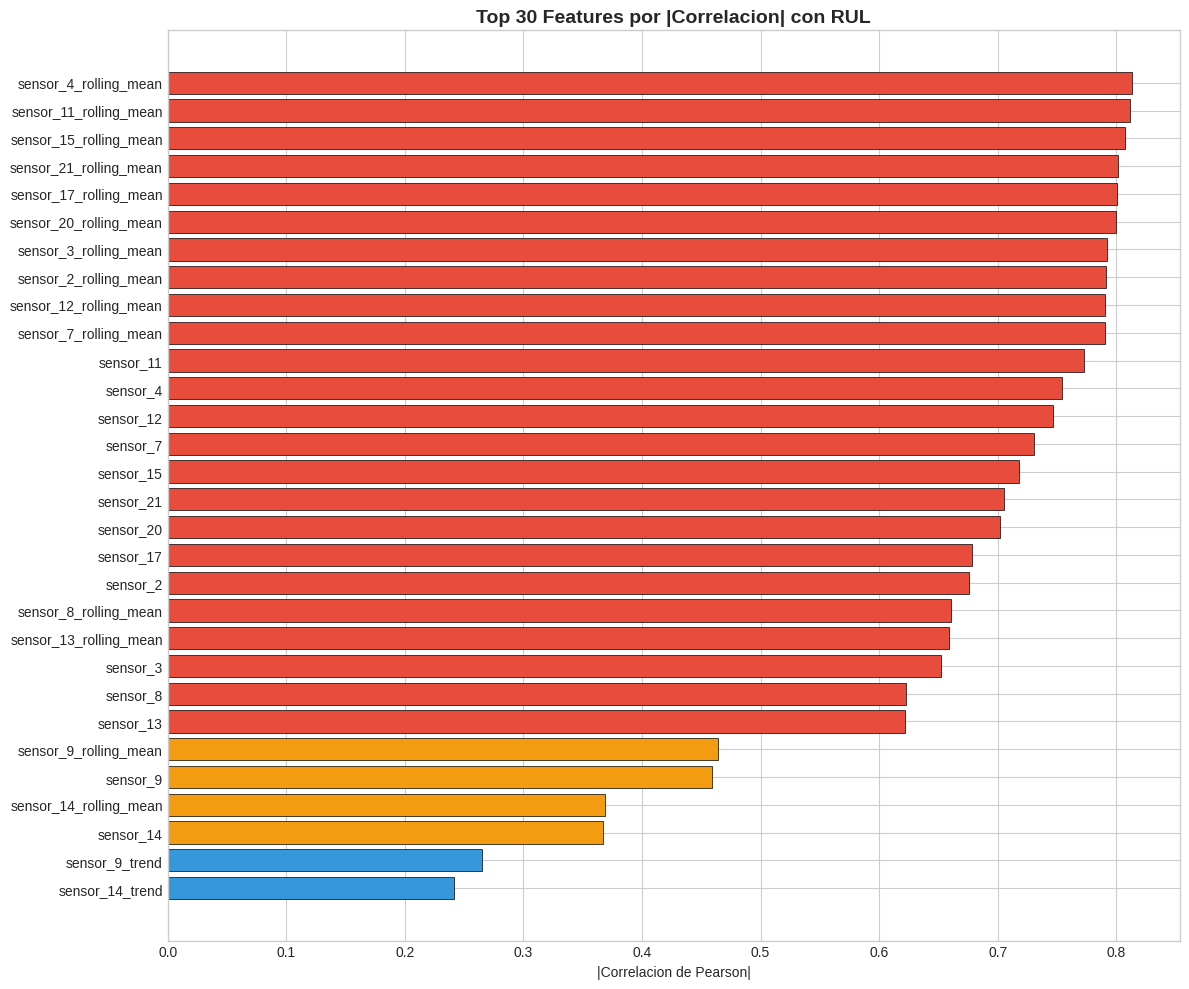

In [6]:
# Obtener todas las feature columns (excluyendo unit, time_cycles, RUL)
all_feature_cols = [c for c in df_feat.columns if c not in ['unit', 'time_cycles', 'RUL']]
print(f"Total features: {len(all_feature_cols)}")

# Correlacion con RUL
correlations = df_feat[all_feature_cols].corrwith(df_feat['RUL']).abs().sort_values(ascending=False)

# Top 30 features por correlacion
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 30
top_corr = correlations.head(top_n)
colors = [CRITICAL if c > 0.5 else DEGRADED if c > 0.3 else NEUTRAL for c in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_title(f'Top {top_n} Features por |Correlacion| con RUL', fontsize=14, fontweight='bold')
ax.set_xlabel('|Correlacion de Pearson|')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

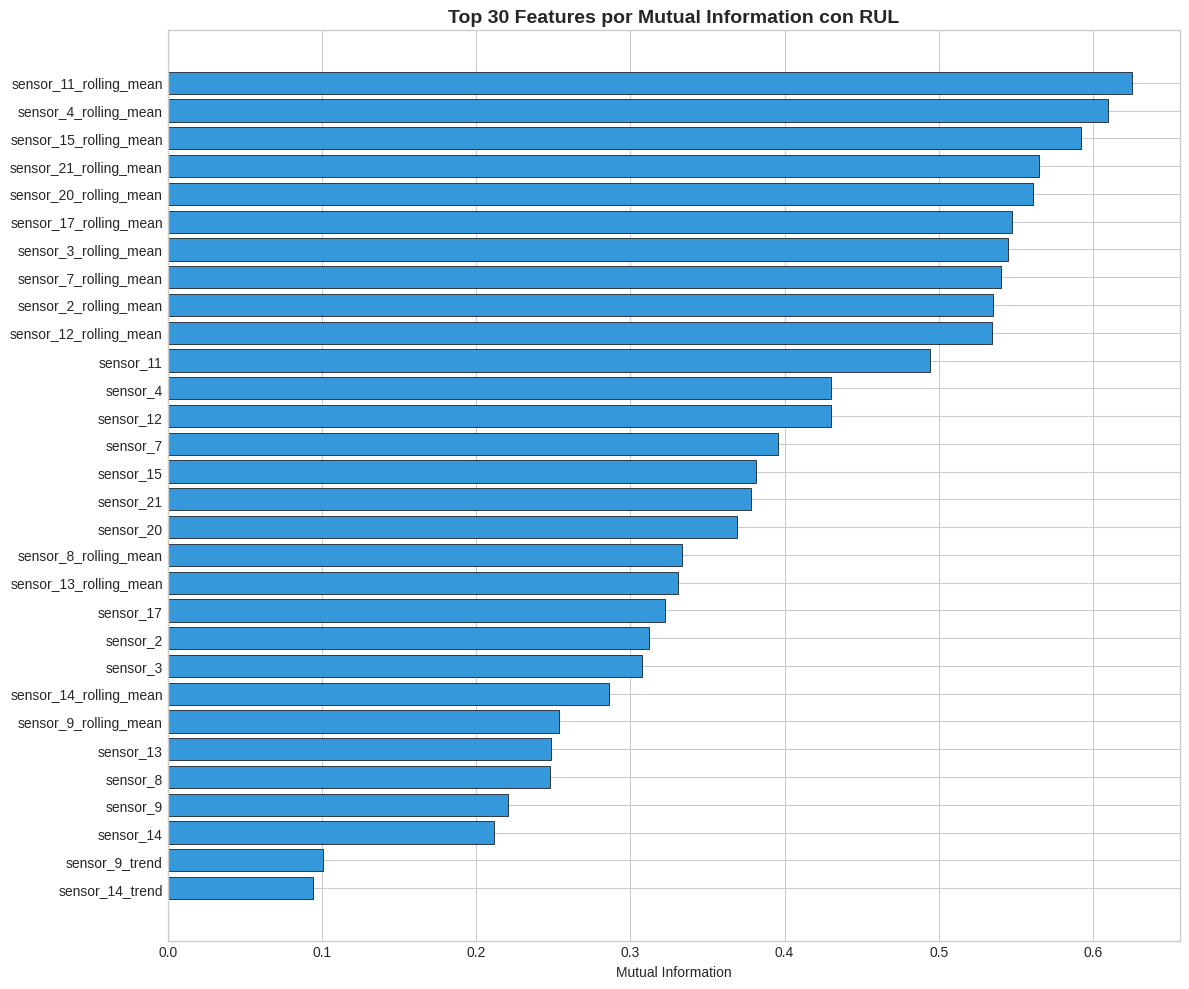

In [7]:
# Mutual information (subset para velocidad)
sample = df_feat.sample(n=min(5000, len(df_feat)), random_state=42)
mi_scores = mutual_info_regression(sample[all_feature_cols].fillna(0), sample['RUL'], random_state=42)
mi_series = pd.Series(mi_scores, index=all_feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_mi = mi_series.head(top_n)
ax.barh(range(len(top_mi)), top_mi.values, color=NEUTRAL, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi.index)
ax.set_title(f'Top {top_n} Features por Mutual Information con RUL', fontsize=14, fontweight='bold')
ax.set_xlabel('Mutual Information')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Preparar Datos de Test

El test set tiene motores cortados antes del fallo. El archivo `RUL_FD001.txt` contiene el RUL real del **ultimo ciclo** de cada motor en test.

In [8]:
# Cargar test
columns = ['unit', 'time_cycles', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]
df_test = pd.read_csv(os.path.join(data_dir, 'test_FD001.txt'),
                       sep=r'\s+', header=None, names=columns)

# Cargar RUL ground truth
rul_test = pd.read_csv(os.path.join(data_dir, 'RUL_FD001.txt'),
                        sep=r'\s+', header=None, names=['RUL_true'])
rul_test['unit'] = rul_test.index + 1

print(f"Test shape: {df_test.shape}")
print(f"Motores en test: {df_test['unit'].nunique()}")
print(f"RUL ground truth: {len(rul_test)} motores")

Test shape: (13096, 26)
Motores en test: 100
RUL ground truth: 100 motores


In [9]:
# Aplicar mismo pipeline al test

# 1. Eliminar constantes
df_test.drop(columns=constant_cols, inplace=True)

# 2. Calcular RUL para cada ciclo del test
max_test_cycles = df_test.groupby('unit')['time_cycles'].max().reset_index()
max_test_cycles.columns = ['unit', 'max_cycle']
df_test = df_test.merge(max_test_cycles, on='unit', how='left')
df_test = df_test.merge(rul_test[['unit', 'RUL_true']], on='unit', how='left')

# RUL de cada ciclo = RUL_ultimo_ciclo + (max_cycle - current_cycle)
df_test['RUL'] = df_test['RUL_true'] + (df_test['max_cycle'] - df_test['time_cycles'])
df_test['RUL'] = df_test['RUL'].clip(upper=130)
df_test.drop(columns=['max_cycle', 'RUL_true'], inplace=True)

# 3. Normalizar con el MISMO scaler del train (solo transform, NUNCA fit)
df_test_norm = df_test.copy()
df_test_norm[feature_cols] = scaler.transform(df_test_norm[feature_cols])

print("Test normalizado con scaler del TRAIN (no fit, solo transform)")
print(f"Verificacion test (sensor_2): min={df_test_norm['sensor_2'].min():.4f}, max={df_test_norm['sensor_2'].max():.4f}")

# 4. Rolling features
test_rolling = []
for unit in df_test_norm['unit'].unique():
    unit_data = df_test_norm[df_test_norm['unit'] == unit].copy().sort_values('time_cycles')
    for sensor in sensor_cols:
        unit_data[f'{sensor}_rolling_mean'] = unit_data[sensor].rolling(window=WINDOW, min_periods=1).mean()
        unit_data[f'{sensor}_rolling_std'] = unit_data[sensor].rolling(window=WINDOW, min_periods=1).std().fillna(0)
    test_rolling.append(unit_data)
df_test_feat = pd.concat(test_rolling, ignore_index=True)

# 5. Trend features
test_trend = []
for unit in df_test_feat['unit'].unique():
    unit_data = df_test_feat[df_test_feat['unit'] == unit].copy().sort_values('time_cycles')
    for sensor in sensor_cols:
        slopes = []
        values = unit_data[sensor].values
        for i in range(len(values)):
            start = max(0, i - TREND_WINDOW + 1)
            slopes.append(calc_slope(values[start:i+1]))
        unit_data[f'{sensor}_trend'] = slopes
    test_trend.append(unit_data)
df_test_feat = pd.concat(test_trend, ignore_index=True)

print(f"Test procesado shape: {df_test_feat.shape}")

Test normalizado con scaler del TRAIN (no fit, solo transform)
Verificacion test (sensor_2): min=-0.0241, max=0.9307
Test procesado shape: (13096, 61)


## 8. Guardar Datasets Procesados

In [10]:
# Preparar X, y para train
X_train = df_feat.drop(columns=['unit', 'time_cycles', 'RUL'])
y_train = df_feat['RUL']

# Preparar X, y para test (solo ultimo ciclo de cada motor para evaluacion clasica)
last_cycle_idx = df_test_feat.groupby('unit')['time_cycles'].idxmax()
df_test_last = df_test_feat.loc[last_cycle_idx]
X_test_last = df_test_last.drop(columns=['unit', 'time_cycles', 'RUL'])
y_test_last = df_test_last['RUL']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test (ultimo ciclo): {X_test_last.shape}, y_test: {y_test_last.shape}")
print(f"\ny_train stats:\n{y_train.describe()}")
print(f"\ny_test stats:\n{y_test_last.describe()}")

# Guardar todo
df_feat.to_parquet(os.path.join(processed_dir, 'train_features.parquet'), index=False)
df_test_feat.to_parquet(os.path.join(processed_dir, 'test_features.parquet'), index=False)

# Guardar tambien X,y para modelos clasicos (ultimo ciclo de test)
df_test_last.to_parquet(os.path.join(processed_dir, 'test_last_cycle.parquet'), index=False)

print("\nArchivos guardados:")
for f in ['train_features.parquet', 'test_features.parquet', 'test_last_cycle.parquet']:
    path = os.path.join(processed_dir, f)
    print(f"  {f}: {os.path.getsize(path) / 1024:.1f} KB")

X_train: (20631, 58), y_train: (20631,)
X_test (ultimo ciclo): (100, 58), y_test: (100,)

y_train stats:
count    20631.000000
mean        88.727304
std         43.444137
min          0.000000
25%         51.000000
50%        103.000000
75%        130.000000
max        130.000000
Name: RUL, dtype: float64

y_test stats:
count    100.000000
mean      74.920000
std       40.891006
min        7.000000
25%       32.750000
50%       86.000000
75%      112.250000
max      130.000000
Name: RUL, dtype: float64

Archivos guardados:
  train_features.parquet: 6418.7 KB
  test_features.parquet: 4133.8 KB
  test_last_cycle.parquet: 83.4 KB


## Resumen

1. **Columnas eliminadas:** 8 constantes (7 sensores + op3)
2. **Normalizacion:** MinMaxScaler por motor [0, 1]
3. **Rolling features:** Media y std movil (ventana=5) para 14 sensores
4. **Trend features:** Pendiente lineal (ventana=10) para 14 sensores
5. **Total features:** ~56 features derivadas + 16 originales
6. **Test procesado:** Mismo pipeline aplicado al test set

### Siguiente paso
Modelo baseline: Random Forest, XGBoost, SVR — predecir RUL como regresion.